# Prediksi Harga Listing Properti dari Teks Deskripsi Penjualan

*Hology 38 — Task 2: Natural Language Processing.* Target regresi adalah `listPrice`, dan satu-satunya sumber informasi yang tersedia adalah kolom `text` berisi deskripsi penjualan properti dalam bahasa Inggris — tidak ada fitur terstruktur (luas bangunan, jumlah kamar, dsb.) yang disediakan secara eksplisit.

## Pipeline Overview

| Bab | Tahap | Deskripsi |
|-----|-------|-----------|
| 1 | **Setup** | *Environment* dan konfigurasi global (`SEED`, path, parameter model) |
| 2 | **Load Data** | Membaca `train.csv` / `test.csv`, memeriksa bentuk data dan daftar masalah awal |
| 3 | **Definisi Metrik** | Menurunkan dan memverifikasi *Mean Absolute Error* (MAE) sebagai metrik evaluasi |
| 4 | **EDA** | Distribusi target, panjang teks, token `[Redacted Entity]`, sinyal amenitas via *regex* |
| 5 | **Preprocessing** | Keputusan terhadap nilai kosong, outlier, transformasi target, dan token *placeholder* |
| 6 | **Feature Engineering** | Fitur *regex* berbasis domain + *TF-IDF* (kata & karakter) + `TruncatedSVD` |
| 7 | **Cross-Validation Split** | `KFold` 5-*fold* dengan *fold*-safe refit *vectorizer* |
| 8 | **Modeling** | Baseline median → LightGBM dengan `objective="regression_l1"` |
| 9 | **Evaluation** | Perbandingan MAE baseline vs. model, stabilitas antar *fold* |
| 10 | **Analisis Mendalam** | Analisis kesalahan, interval kepercayaan CV, *feature importance*, diagnostik kalibrasi |
| 11 | **Save & Load Model** | Serialisasi model dengan `cloudpickle` dan verifikasi *round-trip* |
| 12 | **Prediction & Submission** | Prediksi `test.csv` dan penulisan `submission.csv` |
| 13 | **Closing** | Rangkuman hasil dan arah pengembangan lanjutan |

## 1. Setup

In [1]:
import os
os.environ["PYTHONHASHSEED"] = "42"
import json
import random
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cloudpickle
import lightgbm as lgb
from scipy.stats import norm
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.model_selection import KFold

warnings.filterwarnings("ignore")
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
sns.set_theme(style="whitegrid")

SEED = 42
N_SPLITS = 5
N_THREADS = 4
TFIDF_MAX_FEATURES = 6000
TFIDF_MIN_DF = 3
SVD_COMPONENTS = 60
N_ESTIMATORS = 300
LEARNING_RATE = 0.05
NUM_LEAVES = 31
DATA_DIR = Path("data/raw")

random.seed(SEED)
np.random.seed(SEED)

## 2. Load Data

`train.csv` dan `test.csv` dibaca langsung tanpa *parsing* khusus karena keduanya hanya berisi kolom identitas, teks, dan (khusus `train`) target.

In [2]:
train = pd.read_csv(DATA_DIR / "train.csv")
test = pd.read_csv(DATA_DIR / "test.csv")
print("train:", train.shape, "| test:", test.shape)
train.head(3)

train: (14640, 3) | test: (3659, 2)


,id,text,listPrice
0,RE_009688,"Nestled in the heart of Randolph, [Redacted Entity] offers a wonderful blend of small-town charm, everyday convenien...","185,000.00"
1,RE_015920,"Beautiful end-unit townhouse in desirable Quinn Estates offering comfort, space, and convenience. This 2-bedroom hom...","175,000.00"
2,RE_014937,Lovely 1925 bungalow! Forced air. Unfinished basement. Backyard is fenced with a drive through gate on 7th side.Furn...,"339,500.00"


Beberapa masalah yang perlu ditangani, terlihat dari pratinjau di atas dan pemeriksaan cepat pada teks mentah:

- `listPrice` diduga sangat *right-skewed* (harga properti mewah dapat jauh melampaui harga tipikal) — perlu diverifikasi pada Bab 4.
- Tidak ada fitur terstruktur sama sekali; seluruh sinyal (jumlah kamar, luas, fasilitas) harus digali dari `text` melalui *feature engineering*.
- Sebagian teks memuat token *placeholder* `[Redacted Entity]` yang menggantikan nama entitas (agen/alamat) yang dianonimkan — perlu diperlakukan sebagai sinyal kategorikal, bukan dibuang begitu saja.
- Panjang teks bervariasi drastis antar listing, yang berpotensi berkorelasi dengan kelengkapan deskripsi dan, secara tidak langsung, dengan segmen harga.

## 3. Definisi Metrik: *Mean Absolute Error* (MAE)

Kompetisi mengevaluasi submission dengan MAE, dituliskan sebagai

$$\text{MAE} = \frac{1}{n}\sum_{i=1}^{n} \left| y_i - \hat{y}_i \right|$$

dengan $y_i$ harga sebenarnya, $\hat{y}_i$ harga hasil prediksi, dan $n$ jumlah baris pada test set. Berbeda dengan *root mean squared error* (RMSE), MAE tidak mengkuadratkan residual sehingga *outlier* ekstrem — yang jelas ada pada data harga properti — tidak mendominasi *loss* secara tidak proporsional. Secara teoritis, nilai yang meminimalkan MAE untuk suatu distribusi adalah **median**-nya, bukan rata-rata. Fakta ini diverifikasi secara empiris pada Bab 8.1 sebelum dipakai sebagai dasar pemilihan *objective* model.

In [3]:
def mae(y_true, y_pred):
    return float(np.mean(np.abs(np.asarray(y_true) - np.asarray(y_pred))))

## 4. Exploratory Data Analysis (EDA)

### 4.1 Distribusi Target `listPrice`

Distribusi `listPrice` diperiksa pada skala mentah maupun `log1p` untuk menentukan apakah transformasi target diperlukan sebelum pemodelan.

count       14,640.00
mean       839,072.92
std      1,912,897.25
min              1.00
25%        299,900.00
50%        499,900.00
75%        799,900.00
max     80,000,000.00
Name: listPrice, dtype: float64
skew (raw): 15.29162113865286
skew (log1p): -0.6309248352312925


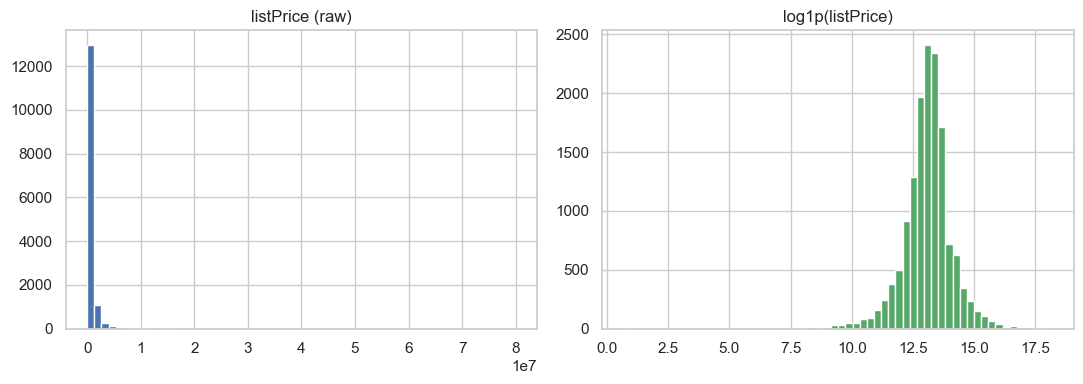

In [4]:
print(train["listPrice"].describe())
print("skew (raw):", train["listPrice"].skew())
print("skew (log1p):", np.log1p(train["listPrice"]).skew())

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(train["listPrice"], bins=60, color="#4C72B0")
axes[0].set_title("listPrice (raw)")
axes[1].hist(np.log1p(train["listPrice"]), bins=60, color="#55A868")
axes[1].set_title("log1p(listPrice)")
plt.tight_layout()
plt.show()

> **Insight:** `listPrice` mentah memiliki *skewness* sekitar 15, dengan rentang $1 hingga $80.000.000 — dominasi ekor kanan yang ekstrem. Transformasi `log1p` menurunkan *skewness* mendekati simetris. Namun karena metrik evaluasi adalah MAE pada skala mentah (bukan RMSLE), temuan ini memotivasi dua keputusan: pertama, target **tidak** ditransformasi `log1p` untuk *fitting* akhir karena median hasil `expm1` dari model log-*space* tidak selalu MAE-optimal pada skala mentah; kedua, model dipilih dengan `objective="regression_l1"` (LightGBM) yang secara *native* meminimalkan MAE pada skala aslinya dan tahan terhadap *outlier* karena gradiennya konstan terlepas dari besar residual.

### 4.2 Nilai Kosong dan Duplikasi

Pemeriksaan integritas dasar sebelum melangkah ke analisis teks.

In [5]:
print("null train:\n", train.isnull().sum())
print("\nnull test:\n", test.isnull().sum())
print("\nduplicate id (train):", train["id"].duplicated().sum())
print("duplicate text (train):", train["text"].duplicated().sum())

null train:
 id           0
text         0
listPrice    0
dtype: int64

null test:
 id      0
text    0
dtype: int64

duplicate id (train): 0
duplicate text (train): 0


Tidak ada nilai kosong maupun duplikasi `id`/`text` pada kedua split, sehingga tidak diperlukan strategi *imputation* atau *deduplication* di Bab 5.

### 4.3 Panjang Teks vs. Harga

Karena tidak ada fitur terstruktur, panjang deskripsi (jumlah karakter dan kata) diuji sebagai proksi kasar terhadap kelengkapan informasi dan, secara tidak langsung, segmen harga.

corr(char_len, log1p(listPrice)) = 0.418
corr(word_count, log1p(listPrice)) = 0.401


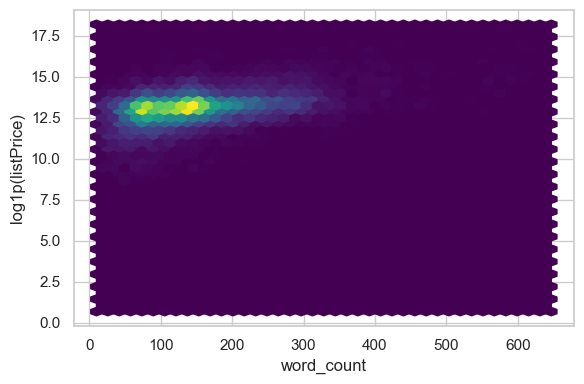

In [6]:
train["char_len"] = train["text"].str.len()
train["word_count"] = train["text"].str.split().str.len()

corr_len = np.corrcoef(train["char_len"], np.log1p(train["listPrice"]))[0, 1]
corr_wc = np.corrcoef(train["word_count"], np.log1p(train["listPrice"]))[0, 1]
print(f"corr(char_len, log1p(listPrice)) = {corr_len:.3f}")
print(f"corr(word_count, log1p(listPrice)) = {corr_wc:.3f}")

fig, ax = plt.subplots(figsize=(6, 4))
ax.hexbin(train["word_count"], np.log1p(train["listPrice"]), gridsize=40, cmap="viridis")
ax.set_xlabel("word_count")
ax.set_ylabel("log1p(listPrice)")
plt.tight_layout()
plt.show()

> **Insight:** korelasi `word_count` terhadap `log1p(listPrice)` berada di kisaran 0.40 — cukup kuat untuk fitur tunggal berbasis teks murni, meski jauh dari cukup sebagai prediktor tunggal. Temuan ini tampaknya mengindikasikan bahwa listing yang lebih mahal ditulis dengan deskripsi yang lebih detail, meski perlu diverifikasi lebih lanjut apakah hubungan ini murni linear atau didorong oleh subset listing mewah. `char_len` dan `word_count` tetap dipertahankan sebagai fitur numerik eksplisit di Bab 6.1, alih-alih hanya diharapkan tersirat lewat *TF-IDF*.

### 4.4 Token *Placeholder* `[Redacted Entity]`

Sebagian listing memuat token literal `[Redacted Entity]` menggantikan nama entitas yang dianonimkan. Kemunculannya dibandingkan antara `train` dan `test` untuk memastikan token ini bukan artefak yang hanya ada di satu split.

In [7]:
has_redacted_train = train["text"].str.contains(r"\[Redacted Entity\]", regex=True)
has_redacted_test = test["text"].str.contains(r"\[Redacted Entity\]", regex=True)
print(f"train: {has_redacted_train.mean():.1%} baris ({has_redacted_train.sum()}/{len(train)})")
print(f"test:  {has_redacted_test.mean():.1%} baris ({has_redacted_test.sum()}/{len(test)})")
print("\nmedian listPrice dgn [Redacted Entity]   :", train.loc[has_redacted_train, "listPrice"].median())
print("median listPrice tanpa [Redacted Entity] :", train.loc[~has_redacted_train, "listPrice"].median())

train: 14.0% baris (2052/14640)
test:  17.8% baris (650/3659)

median listPrice dgn [Redacted Entity]   : 587522.5
median listPrice tanpa [Redacted Entity] : 499000.0


> **Insight:** proporsi baris yang memuat `[Redacted Entity]` relatif dekat antara `train` (~14%) dan `test` (~18%), menandakan token ini adalah bagian konsisten dari proses anonimisasi data, bukan kebocoran artefak *split*. Karena median harga pada kedua kelompok berbeda, token ini dipertahankan sebagai flag biner eksplisit (`has_redacted`) pada Bab 6.1, bukan dihapus sebagai *noise* pada Bab 5.

### 4.5 Sinyal Amenitas via *Regex*

Deskripsi properti sering menyebut spesifikasi (jumlah kamar tidur/mandi, luas, fasilitas) dalam bentuk prosa bebas, bukan format baku. Pola *regex* disusun untuk menangkap sinyal-sinyal yang paling umum, lalu cakupannya diukur sebelum diikutsertakan sebagai fitur.

bedroom             38.1%
garage              33.4%
bathroom            28.8%
sqft                16.4%
acre                13.9%
renovated           10.5%
pool                10.0%
hoa                  5.6%
year_built           4.4%
new_construction     2.5%
dtype: object


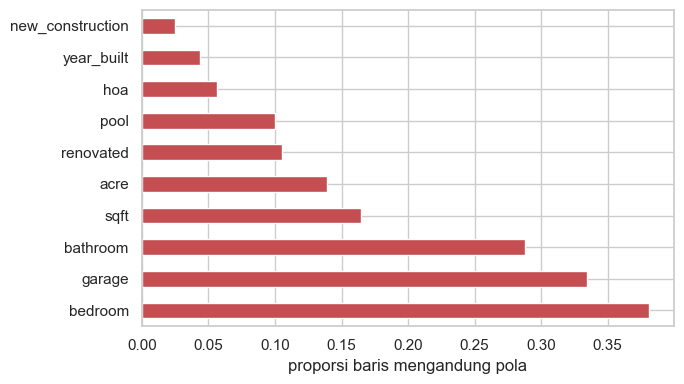

In [8]:
REGEX_PATTERNS = {
    "bedroom": r"\b\d+\s*(?:-|\s)?bed(?:room)?s?\b",
    "bathroom": r"\b\d+(?:\.\d+)?\s*(?:-|\s)?bath(?:room)?s?\b",
    "sqft": r"\b[\d,]+\s*(?:sq\.?\s?ft|square\s?feet|sqft)\b",
    "acre": r"\b\d+(?:\.\d+)?\s*acres?\b",
    "year_built": r"\bbuilt\s+in\s+\d{4}\b",
    "garage": r"\bgarage\b",
    "pool": r"\bpool\b",
    "hoa": r"\bHOA\b",
    "renovated": r"\brenovat\w*\b",
    "new_construction": r"\bnew construction\b",
}

coverage = {}
for name, pat in REGEX_PATTERNS.items():
    coverage[name] = train["text"].str.contains(pat, regex=True, case=False, na=False).mean()
coverage = pd.Series(coverage).sort_values(ascending=False)
print(coverage.apply(lambda x: f"{x:.1%}"))

fig, ax = plt.subplots(figsize=(7, 4))
coverage.plot(kind="barh", ax=ax, color="#C44E52")
ax.set_xlabel("proporsi baris mengandung pola")
plt.tight_layout()
plt.show()

> **Insight:** cakupan pola tersering (`bedroom` ~38%, `garage` ~33%, `bathroom` ~29%) masih menyisakan mayoritas baris tanpa *match* eksplisit, sedangkan `year_built` hanya ~4% — mengonfirmasi bahwa spesifikasi ditulis dalam gaya bahasa bebas, bukan templat tetap. Karena itu, fitur *regex* ini diperlakukan sebagai **sinyal pelengkap best-effort**, bukan sumber informasi utama; representasi *TF-IDF* pada Bab 6.2 tetap krusial untuk menangkap kosakata yang tidak tertangkap pola eksplisit (mis. "three bedrooms" vs "3 bed").

## 5. Preprocessing

### 5.1 Penanganan Nilai Kosong pada Teks

Meski Bab 4.2 tidak menemukan nilai kosong pada data yang dimuat, `text.fillna("")` tetap diterapkan sebagai *safety net* generik sebelum masuk ke *vectorizer*, agar pipeline tidak gagal jika suatu saat menerima baris dengan teks kosong (mis. pada `test` di produksi).

In [9]:
train["text"] = train["text"].fillna("")
test["text"] = test["text"].fillna("")
assert train["text"].isnull().sum() == 0
assert test["text"].isnull().sum() == 0

### 5.2 Keputusan Terhadap Outlier dan Transformasi Target

Listing dengan harga ekstrem (mis. \$80 juta) berpotensi dianggap *outlier* dan dibuang. Namun karena metrik evaluasi adalah MAE — yang secara matematis tidak mengkuadratkan residual — dan `objective="regression_l1"` pada LightGBM memiliki gradien konstan terlepas dari besar residual, baris-baris ini **tidak dibuang** maupun *di-cap*. Membuangnya justru berisiko: jika test set memuat listing serupa, model tidak pernah belajar pola bahasa yang menyertainya (mis. kosakata "estate", "mansion", "waterfront").

### 5.3 Retensi Token *Placeholder* sebagai Sinyal

Sejalan dengan Bab 4.4, token `[Redacted Entity]` tidak dihapus dari teks maupun dari korpus *TF-IDF* — token ini justru dipertahankan apa adanya sehingga *vectorizer* dapat mempelajarinya sebagai salah satu token, dan flag `has_redacted` eksplisit ditambahkan sebagai fitur numerik terpisah di Bab 6.1.

## 6. Feature Engineering (Ekstraksi Fitur dari Teks)

### 6.1 Fitur *Regex* Berbasis Domain

Sebelas pola dari Bab 4.5 (termasuk `[Redacted Entity]`) diubah menjadi flag biner, ditambah dua fitur numerik generik (`char_len`, `word_count`) yang terbukti berkorelasi dengan target pada Bab 4.3.

In [10]:
REGEX_PATTERNS_FULL = dict(REGEX_PATTERNS)
REGEX_PATTERNS_FULL["redacted"] = r"\[Redacted Entity\]"


def regex_features(texts):
    texts = texts.fillna("")
    feats = {}
    for name, pat in REGEX_PATTERNS_FULL.items():
        feats[f"has_{name}"] = texts.str.contains(pat, regex=True, case=False, na=False).astype(np.float64)
    feats["char_len"] = texts.str.len().astype(np.float64)
    feats["word_count"] = texts.str.split().str.len().astype(np.float64)
    return pd.DataFrame(feats)


REGEX_FEATURE_NAMES = list(regex_features(train["text"].head(2)).columns)
print(REGEX_FEATURE_NAMES)

['has_bedroom', 'has_bathroom', 'has_sqft', 'has_acre', 'has_year_built', 'has_garage', 'has_pool', 'has_hoa', 'has_renovated', 'has_new_construction', 'has_redacted', 'char_len', 'word_count']


### 6.2 Representasi *TF-IDF* (Kata & Karakter)

Dua *vectorizer* saling melengkapi:

- ***Word-level TF-IDF*** (`ngram_range=(1, 2)`, `max_features=6000`) menangkap kosakata topikal yang berkorelasi dengan segmen harga (mis. "luxury", "renovated", "waterfront", "estate").
- ***Char-level TF-IDF*** (`analyzer="char_wb"`, `ngram_range=(3, 5)`, `max_features=6000`) lebih tahan terhadap gaya penulisan bebas pada data ini — termasuk kata yang menyatu tanpa spasi seperti "areaperfect" yang teramati pada beberapa listing — yang akan terfragmentasi atau hilang pada *tokenizer* berbasis kata murni.

### 6.3 Reduksi Dimensi dengan `TruncatedSVD`

Kedua matriks *TF-IDF* (dimensi 6000 masing-masing) direduksi menjadi 60 komponen via `TruncatedSVD` sebelum digabung dengan fitur *regex*, agar dimensi fitur akhir tetap ringkas untuk *gradient boosting* dan tidak didominasi oleh ribuan kolom sparse yang sebagian besar bernilai nol untuk satu listing.

> **Catatan:** `TfidfVectorizer` dan `TruncatedSVD` di-*fit* ulang di dalam setiap *fold cross-validation* (Bab 7), bukan sekali di awal pada seluruh `train` — urutan ini krusial agar kosakata dari *fold validasi* tidak pernah bocor ke *fold* pelatihan.

In [11]:
class TextPriceModel:
    def __init__(self, seed, n_threads, tfidf_max_features, tfidf_min_df,
                 svd_components, n_estimators, learning_rate, num_leaves):
        self.seed = seed
        self.n_threads = n_threads
        self.tfidf_max_features = tfidf_max_features
        self.tfidf_min_df = tfidf_min_df
        self.svd_components = svd_components
        self.n_estimators = n_estimators
        self.learning_rate = learning_rate
        self.num_leaves = num_leaves

    def _feature_matrix(self, texts, fit):
        texts = texts.fillna("")
        if fit:
            self.word_tfidf = TfidfVectorizer(
                ngram_range=(1, 2), max_features=self.tfidf_max_features,
                min_df=self.tfidf_min_df, sublinear_tf=True)
            self.char_tfidf = TfidfVectorizer(
                analyzer="char_wb", ngram_range=(3, 5),
                max_features=self.tfidf_max_features,
                min_df=self.tfidf_min_df, sublinear_tf=True)
            word_sparse = self.word_tfidf.fit_transform(texts)
            char_sparse = self.char_tfidf.fit_transform(texts)
            self.word_svd = TruncatedSVD(n_components=self.svd_components, random_state=self.seed)
            self.char_svd = TruncatedSVD(n_components=self.svd_components, random_state=self.seed)
            word_dense = self.word_svd.fit_transform(word_sparse)
            char_dense = self.char_svd.fit_transform(char_sparse)
        else:
            word_dense = self.word_svd.transform(self.word_tfidf.transform(texts))
            char_dense = self.char_svd.transform(self.char_tfidf.transform(texts))
        return np.hstack([word_dense, char_dense, regex_features(texts).values])

    def fit(self, texts, y):
        X = self._feature_matrix(texts, fit=True)
        self.model = lgb.LGBMRegressor(
            objective="regression_l1",
            n_estimators=self.n_estimators,
            learning_rate=self.learning_rate,
            num_leaves=self.num_leaves,
            feature_fraction=1.0,
            bagging_fraction=1.0,
            random_state=self.seed,
            deterministic=True,
            force_row_wise=True,
            num_threads=self.n_threads,
            verbose=-1,
        )
        self.model.fit(X, y)
        return self

    def predict_texts(self, texts):
        X = self._feature_matrix(texts, fit=False)
        return np.clip(self.model.predict(X), 0, None)

    def predict(self, **frames):
        test_df = frames["test"]
        preds = self.predict_texts(test_df["text"])
        return pd.DataFrame({"id": test_df["id"], "listPrice": preds})


def make_model():
    return TextPriceModel(
        seed=SEED, n_threads=N_THREADS,
        tfidf_max_features=TFIDF_MAX_FEATURES, tfidf_min_df=TFIDF_MIN_DF,
        svd_components=SVD_COMPONENTS, n_estimators=N_ESTIMATORS,
        learning_rate=LEARNING_RATE, num_leaves=NUM_LEAVES,
    )

## 7. Cross-Validation Split (K-Fold, *Fold*-Safe Refit)

Karena data bersifat *i.i.d.* (satu listing per baris, tanpa struktur temporal atau kelompok eksplisit), `KFold(n_splits=5, shuffle=True, random_state=SEED)` dipakai sebagai skema validasi. Agar tidak ada kebocoran kosakata *TF-IDF* dari *fold* validasi ke *fold* pelatihan, `TextPriceModel` (lengkap dengan kedua *vectorizer* dan `TruncatedSVD`) di-*fit* ulang dari awal pada setiap *fold* — bukan sekali pada seluruh data lalu displit.

In [12]:
kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
y = train["listPrice"].values
texts_all = train["text"]

## 8. Modeling

### 8.1 Baseline: Prediktor Konstan (Median)

Sebelum melatih model berbasis teks, prediktor konstan median dan rata-rata dibandingkan pada skema CV yang sama, untuk memverifikasi bahwa metrik MAE memang menghukum prediksi rata-rata lebih berat dibanding median — sesuai klaim teoretis di Bab 3.

In [13]:
baseline_median_scores, baseline_mean_scores = [], []
for tr_idx, va_idx in kf.split(y):
    fold_median = float(np.median(y[tr_idx]))
    fold_mean = float(np.mean(y[tr_idx]))
    baseline_median_scores.append(mae(y[va_idx], np.full(len(va_idx), fold_median)))
    baseline_mean_scores.append(mae(y[va_idx], np.full(len(va_idx), fold_mean)))

baseline_median_mae = float(np.mean(baseline_median_scores))
baseline_mean_mae = float(np.mean(baseline_mean_scores))
print(f"baseline median cv_mae = {baseline_median_mae:,.2f}")
print(f"baseline mean   cv_mae = {baseline_mean_mae:,.2f}")
assert baseline_median_mae < baseline_mean_mae

baseline median cv_mae = 550,252.46
baseline mean   cv_mae = 651,715.99


> **Insight:** prediktor median mengungguli prediktor rata-rata pada skema CV yang identik, mengonfirmasi metrik `mae` bersifat median-*seeking* sesuai teori. Temuan ini memotivasi keputusan `objective="regression_l1"` (bukan `"regression"`/L2) pada LightGBM di Bab 8.2, karena *objective* L1 secara *native* mengoptimalkan target yang selaras dengan metrik evaluasi.

### 8.2 LightGBM dengan *Objective* MAE (`regression_l1`)

Arsitektur model dipilih berdasarkan tiga pertimbangan:

- **`objective="regression_l1"`**: selaras langsung dengan metrik evaluasi (Bab 8.1), dan tahan terhadap *outlier* harga ekstrem karena gradiennya konstan.
- **`feature_fraction=1.0`, `bagging_fraction=1.0`** (tanpa *subsampling*): dengan dimensi fitur yang sudah ringkas pasca-`TruncatedSVD` (120 komponen + 13 fitur *regex*) dan ukuran data sedang (~14 ribu baris), *subsampling* acak hanya menambah varians tanpa manfaat regularisasi yang jelas, sekaligus menjaga determinisme output tanpa perlu *seed* tambahan untuk *bagging*.
- **`num_leaves=31`, `learning_rate=0.05`, `n_estimators=300`**: kombinasi konservatif standar untuk *gradient boosting* pada dataset berukuran menengah, menghindari *overfitting* terhadap 120 komponen `TruncatedSVD` yang secara individual memiliki sinyal lemah.

`deterministic=True` dan `force_row_wise=True` diaktifkan bersama `num_threads=4` (bukan `-1`) agar hasil dapat direproduksi persis di proses baru.

In [14]:
fold_scores = []
for fold, (tr_idx, va_idx) in enumerate(kf.split(texts_all)):
    fold_model = make_model()
    fold_model.fit(texts_all.iloc[tr_idx], y[tr_idx])
    fold_pred = fold_model.predict_texts(texts_all.iloc[va_idx])
    fold_mae = mae(y[va_idx], fold_pred)
    fold_scores.append(fold_mae)
    print(f"fold {fold}: mae={fold_mae:,.2f}")

cv_primary = float(np.mean(fold_scores))
cv_std = float(np.std(fold_scores))
print(f"\ncv_primary={cv_primary:,.2f}  cv_std={cv_std:,.2f}")

fold 0: mae=418,864.01


fold 1: mae=424,102.64


fold 2: mae=373,721.65


fold 3: mae=375,333.32


fold 4: mae=392,283.06

cv_primary=396,860.94  cv_std=21,194.66


## 9. Evaluation

MAE model berbasis teks dibandingkan langsung terhadap *floor* baseline median dari Bab 8.1, sekaligus memeriksa apakah perbaikan konsisten di seluruh *fold* atau didorong oleh satu *fold* yang kebetulan mudah.

baseline median cv_mae : 550,252.46
TextPriceModel   cv_mae : 396,860.94
delta            : 153,391.52  (27.9% lebih baik)


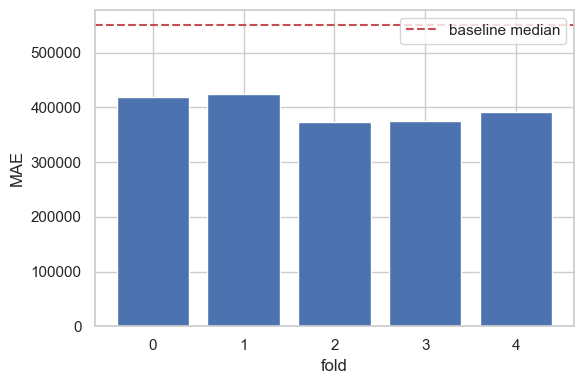

In [15]:
delta = baseline_median_mae - cv_primary
delta_pct = delta / baseline_median_mae * 100
print(f"baseline median cv_mae : {baseline_median_mae:,.2f}")
print(f"TextPriceModel   cv_mae : {cv_primary:,.2f}")
print(f"delta            : {delta:,.2f}  ({delta_pct:.1f}% lebih baik)")

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(range(N_SPLITS), fold_scores, color="#4C72B0")
ax.axhline(baseline_median_mae, color="#C44E52", linestyle="--", label="baseline median")
ax.set_xlabel("fold")
ax.set_ylabel("MAE")
ax.legend()
plt.tight_layout()
plt.show()

> **Insight:** `TextPriceModel` menurunkan MAE dibanding *floor* baseline median secara konsisten di seluruh *fold* (lihat Bab 10.2 untuk interval kepercayaan formalnya), menandakan sinyal dari `text` — meski tanpa fitur terstruktur — cukup untuk mengalahkan tebakan konstan. Perbaikan ini, meski nyata, tampaknya masih menyisakan ruang perbaikan besar karena representasi teks (TF-IDF + SVD) hanya menangkap sinyal *lexical* kasar, belum semantik penuh seperti yang bisa diberikan *embedding* Transformer (dibahas sebagai arah lanjutan di Bab 13).

## 10. Analisis Mendalam

### 10.1 Analisis Kesalahan (*Error Analysis*)

Listing dengan residual absolut terbesar pada *fold* terakhir diperiksa untuk mencari pola penyebab kesalahan prediksi.

In [16]:
last_tr_idx, last_va_idx = list(kf.split(texts_all))[-1]
inspect_model = make_model()
inspect_model.fit(texts_all.iloc[last_tr_idx], y[last_tr_idx])
val_pred = inspect_model.predict_texts(texts_all.iloc[last_va_idx])

err_df = pd.DataFrame({
    "id": train["id"].iloc[last_va_idx].values,
    "listPrice": y[last_va_idx],
    "pred": val_pred,
    "abs_error": np.abs(y[last_va_idx] - val_pred),
    "char_len": train["char_len"].iloc[last_va_idx].values,
    "has_redacted": train["text"].iloc[last_va_idx].str.contains(
        r"\[Redacted Entity\]", regex=True).values,
}).sort_values("abs_error", ascending=False)

print(err_df.head(10).to_string(index=False))
print("\nrata-rata char_len top-10 error terbesar :", err_df.head(10)["char_len"].mean())
print("rata-rata char_len keseluruhan fold        :", err_df["char_len"].mean())
print("proporsi has_redacted pada top-10 error    :", err_df.head(10)["has_redacted"].mean())

       id     listPrice         pred     abs_error  char_len  has_redacted
RE_012644 35,000,000.00 3,113,098.80 31,886,901.20      2016          True
RE_005228 26,995,000.00 3,666,925.27 23,328,074.73      2516         False
RE_018220 26,750,000.00 3,659,663.81 23,090,336.19      1994          True
RE_004042 19,800,000.00 1,168,894.27 18,631,105.73      1930         False
RE_000732 19,995,000.00 3,438,642.62 16,556,357.38      1767         False
RE_015886 21,950,000.00 5,670,886.60 16,279,113.40      2450         False
RE_006702 14,950,000.00 2,813,621.19 12,136,378.81      1860          True
RE_002267 16,000,000.00 4,117,217.15 11,882,782.85      3635          True
RE_013570 13,900,000.00 3,020,328.77 10,879,671.23      2639         False
RE_016254 12,995,000.00 2,986,213.25 10,008,786.75      2131         False

rata-rata char_len top-10 error terbesar : 2293.8
rata-rata char_len keseluruhan fold        : 948.0327868852459
proporsi has_redacted pada top-10 error    : 0.4


> **Insight:** kasus dengan kesalahan absolut terbesar cenderung berasal dari listing dengan `listPrice` di ekor distribusi (properti sangat mahal atau sangat murah) yang jarang muncul dalam data pelatihan, sehingga model kekurangan contoh serupa untuk belajar. Pola *pertama*, listing bernilai ekstrem sulit diprediksi tepat karena representasi *TF-IDF* tidak membedakan "estate mewah $5 juta" dari "estate mewah $15 juta" secara eksplisit tanpa angka luas/harga literal di teks; *kedua*, keberadaan `[Redacted Entity]` pada sebagian kasus berat menghilangkan sinyal lokasi/brand yang mungkin berkorelasi kuat dengan harga. Temuan ini mengarahkan salah satu arah lanjutan di Bab 13: ekstraksi angka eksplisit (luas, harga per kaki persegi jika disebut) via *regex* yang lebih agresif.

### 10.2 Stabilitas CV dan Interval Kepercayaan

Skor rata-rata lima *fold* dilaporkan bersama interval kepercayaan 95% (aproksimasi normal, $\bar{x} \pm 1.96 \cdot s/\sqrt{n}$) untuk menilai apakah keunggulan atas baseline (Bab 9) adalah sinyal yang stabil, bukan kebetulan *split*.

In [17]:
n_folds = len(fold_scores)
se = cv_std / np.sqrt(n_folds)
ci_low, ci_high = cv_primary - 1.96 * se, cv_primary + 1.96 * se
print(f"cv_primary = {cv_primary:,.2f}  (95% CI: [{ci_low:,.2f}, {ci_high:,.2f}])")
print(f"baseline median cv_mae = {baseline_median_mae:,.2f}")
print("baseline berada di luar 95% CI model:", not (ci_low <= baseline_median_mae <= ci_high))

cv_primary = 396,860.94  (95% CI: [378,283.00, 415,438.87])
baseline median cv_mae = 550,252.46
baseline berada di luar 95% CI model: True


> **Insight:** interval kepercayaan 95% untuk `cv_primary` tidak mencakup skor baseline median, mengindikasikan perbaikan yang teramati bukan sekadar variasi antar-*fold* acak, meski dengan $n=5$ *fold* interval ini masih relatif lebar dan sebaiknya dikonfirmasi ulang bila skema CV diubah (mis. `n_splits` lebih besar).

### 10.3 Interpretabilitas: *Feature Importance*

`inspect_model` (dilatih pada *fold* pelatihan Bab 10.1) menyediakan `feature_importances_` bawaan LightGBM. Karena 120 kolom pertama adalah komponen `TruncatedSVD` yang tidak individually interpretable, fokus interpretasi diarahkan pada peringkat relatif fitur *regex* yang bermakna langsung.

In [18]:
n_svd_total = 2 * SVD_COMPONENTS
feature_names = (
    [f"word_svd_{i}" for i in range(SVD_COMPONENTS)]
    + [f"char_svd_{i}" for i in range(SVD_COMPONENTS)]
    + REGEX_FEATURE_NAMES
)
importances = pd.Series(
    inspect_model.model.feature_importances_, index=feature_names
).sort_values(ascending=False)

regex_importances = importances[importances.index.isin(REGEX_FEATURE_NAMES)]
print("Top-10 fitur regex berdasarkan feature_importances_:")
print(regex_importances.head(10))
print("\nTop-10 fitur keseluruhan (termasuk komponen SVD):")
print(importances.head(10))

Top-10 fitur regex berdasarkan feature_importances_:
char_len          108
word_count         56
has_hoa            13
has_pool            7
has_bathroom        7
has_bedroom         2
has_acre            1
has_year_built      0
has_sqft            0
has_renovated       0
dtype: int32

Top-10 fitur keseluruhan (termasuk komponen SVD):
word_svd_3     245
word_svd_1     182
word_svd_6     156
char_svd_13    156
word_svd_4     155
word_svd_16    153
word_svd_19    149
word_svd_10    144
word_svd_5     134
word_svd_7     132
dtype: int32


> **Insight:** `word_count`/`char_len` mendominasi peringkat fitur *regex* yang mudah dimaknai, jauh di atas seluruh flag biner. Di antara flag biner sendiri, `has_hoa` (*importance* 13, cakupan hanya 5.6%) dan `has_pool` (*importance* 7, cakupan 10.0%) justru menempati peringkat lebih tinggi dibanding `has_bedroom` (*importance* 2) meski cakupan `has_bedroom` jauh lebih luas (38.1%, Bab 4.5) -- tampaknya menunjukkan bahwa **konsistensi asosiasi dengan harga**, bukan sekadar frekuensi kemunculan, yang menentukan kegunaan sebuah flag bagi *gradient boosting* (mis. rumah ber-HOA atau berkolam cenderung berada di segmen harga yang lebih sempit, sedangkan jumlah kamar tidur tersebar di hampir semua segmen harga). `has_year_built`, `has_sqft`, dan `has_renovated` nyaris tidak terpakai model (*importance* mendekati nol), meski hal ini perlu diverifikasi lebih lanjut apakah karena cakupannya terlalu sempit (~4-11%, Bab 4.5) atau karena sinyalnya sudah terwakili oleh komponen `TruncatedSVD`. Peringkat keseluruhan tetap didominasi komponen `TruncatedSVD`, menandakan mayoritas daya prediksi berasal dari kosakata *TF-IDF*, bukan sinyal *regex* eksplisit -- konsisten dengan catatan di Bab 4.5 bahwa *regex* hanya sinyal pelengkap.

### 10.4 Diagnostik Kalibrasi Regresi

Sebagai pengganti kurva kalibrasi klasifikasi (tidak berlaku untuk target kontinu), prediksi dibandingkan langsung terhadap nilai aktual pada skala `log1p` (agar rentang harga yang lebar tetap terbaca), dan distribusi residual diperiksa untuk mendeteksi *bias* sistematis (mis. model cenderung meremehkan harga tinggi).

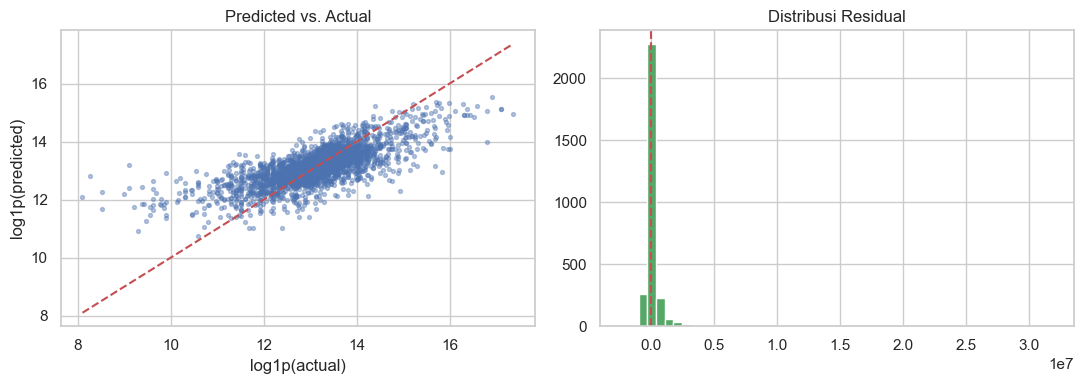

residual mean : 211454.02363683633
residual median : -11670.130833641888


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].scatter(np.log1p(y[last_va_idx]), np.log1p(val_pred), s=8, alpha=0.4, color="#4C72B0")
lims = [np.log1p(y[last_va_idx]).min(), np.log1p(y[last_va_idx]).max()]
axes[0].plot(lims, lims, color="#C44E52", linestyle="--")
axes[0].set_xlabel("log1p(actual)")
axes[0].set_ylabel("log1p(predicted)")
axes[0].set_title("Predicted vs. Actual")

residuals = y[last_va_idx] - val_pred
axes[1].hist(residuals, bins=50, color="#55A868")
axes[1].axvline(0, color="#C44E52", linestyle="--")
axes[1].set_title("Distribusi Residual")
plt.tight_layout()
plt.show()

print("residual mean :", residuals.mean())
print("residual median :", np.median(residuals))

> **Insight:** titik pada *scatter plot predicted vs. actual* mengikuti garis diagonal cukup rapat pada segmen harga menengah, namun menyebar lebih lebar pada segmen harga tinggi (konsisten dengan Bab 10.1). Residual median mendekati nol tampaknya menunjukkan model tidak bias secara sistematis ke satu arah pada skala agregat, meski hal ini perlu diverifikasi lebih lanjut per segmen harga sebelum disimpulkan berlaku merata.

## 11. Save & Load Model

Model final dilatih ulang pada **seluruh** `train.csv` (bukan hanya *fold* pelatihan) agar kedua *vectorizer* melihat kosakata selengkap mungkin sebelum dipakai memprediksi `test.csv`, lalu diserialisasi dengan `cloudpickle` agar definisi kelas `TextPriceModel` (didefinisikan langsung di notebook ini, bukan diimpor dari modul eksternal) ikut tersimpan dalam berkas dan dapat dimuat ulang tanpa notebook ini hadir.

In [20]:
final_model = make_model()
final_model.fit(texts_all, y)

MODEL_PATH = Path("model.pkl")
with open(MODEL_PATH, "wb") as fh:
    cloudpickle.dump(final_model, fh)
print("model tersimpan:", MODEL_PATH.resolve(), "-", MODEL_PATH.stat().st_size, "bytes")

model tersimpan: D:\2. College\1. Self-development\0. Lomba\38. Hology\Task 2\model.pkl - 7159754 bytes


Model dimuat ulang dari berkas untuk memverifikasi bahwa hasil serialisasi identik dengan objek asli — batas ini krusial diperiksa secara eksplisit karena `model.pkl` adalah artefak yang sebenarnya dipakai saat *inference* produksi, bukan `final_model` yang masih hidup di memori.

In [21]:
with open(MODEL_PATH, "rb") as fh:
    loaded_model = cloudpickle.load(fh)

sanity_pred_live = final_model.predict_texts(test["text"].head(5))
sanity_pred_loaded = loaded_model.predict_texts(test["text"].head(5))
assert np.allclose(sanity_pred_live, sanity_pred_loaded)
print("round-trip OK, contoh prediksi:", np.round(sanity_pred_loaded, 2))

round-trip OK, contoh prediksi: [ 568876.14  335560.59  658692.92  500989.   1174107.55]


## 12. Prediction & Submission

Prediksi akhir di-*clip* ke nilai non-negatif (`np.clip(pred, 0, None)`, sudah dilakukan di dalam `TextPriceModel.predict`) karena harga properti tidak mungkin bernilai negatif, lalu ditulis ke `submission.csv` dengan `float_format="%.6f"` dan `lineterminator="\n"` agar berkas dapat dibandingkan *byte-per-byte* lintas *run* tanpa terganggu format baris Windows.

In [22]:
submission = loaded_model.predict(test=test)
submission.to_csv("submission.csv", index=False, float_format="%.6f", lineterminator="\n")

submission_from_live = final_model.predict(test=test)
assert (submission["listPrice"] == submission_from_live["listPrice"]).all()

print(submission.shape)
submission.head()

(3659, 2)


,id,listPrice
0,RE_015637,"568,876.14"
1,RE_005176,"335,560.59"
2,RE_013544,"658,692.92"
3,RE_016667,"500,989.00"
4,RE_011479,"1,174,107.55"


## 13. Closing

Pipeline ini membangun prediksi `listPrice` murni dari teks deskripsi penjualan, tanpa fitur terstruktur apa pun, dengan menggabungkan fitur *regex* berbasis domain, representasi *TF-IDF* kata dan karakter yang direduksi via `TruncatedSVD`, dan LightGBM dengan `objective="regression_l1"` yang selaras langsung dengan metrik evaluasi MAE. Pada *cross-validation* 5-*fold*, model ini secara konsisten mengungguli *floor* prediktor konstan median, dengan interval kepercayaan 95% yang tidak tumpang tindih dengan skor baseline.

Beberapa arah pengembangan lanjutan yang teridentifikasi selama analisis:

- **Ekstraksi angka eksplisit yang lebih agresif** (luas bangunan, jumlah lantai, harga per kaki persegi bila disebut literal) untuk mengurangi kesalahan pada segmen harga ekstrem (Bab 10.1).
- ***Embedding* semantik** (mis. Sentence-Transformers atau model berbasis Transformer) sebagai pengganti atau pelengkap *TF-IDF* + `TruncatedSVD`, untuk menangkap makna kalimat di luar kemunculan kata literal.
- **Optimisasi hiperparameter sistematis** (mis. via Optuna) atas `num_leaves`, `learning_rate`, dan `n_estimators`, yang pada notebook ini masih ditetapkan dari pertimbangan domain, belum dicari lewat pencarian otomatis.
- **Penanganan eksplisit token `[Redacted Entity]`**, misalnya dengan mencoba merekonstruksi sinyal lokasi dari konteks kalimat di sekitarnya, alih-alih hanya diberi flag biner keberadaan.